In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# # 在 notebook 中运行
# import sys
# import subprocess

# # 1. 强制卸载并重新安装
# subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "scikit-learn-extra", "-y"])
# subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "numpy", "-y"])

# # 2. 安装兼容版本的 numpy
# subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy==1.23.5"])

# # 3. 重新编译安装 scikit-learn-extra（不适用预编译包）
# subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn-extra", "--no-binary", "scikit-learn-extra"])

# print("安装完成，请重启内核")

In [3]:
import pandas as pd
import numpy as np

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_samples, silhouette_score
from scipy.cluster.hierarchy import ClusterWarning
from warnings import simplefilter
simplefilter("ignore", ClusterWarning)
random_seed = 2021

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from sklearn.metrics.pairwise import euclidean_distances#transform dataframe into rdm

In [4]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_samples, silhouette_score
from scipy.cluster.hierarchy import ClusterWarning
from warnings import simplefilter
simplefilter("ignore", ClusterWarning)

def optimalK(data_type,data, algorithm1, algorithm2, title, random_state=random_seed, maxClusters=15):
    """
    Calculates optimal K using silhouette score
    Params:
        data_type: df, dissim
        data: ndarry of shape (n_samples, n_features)
        algorithm1: kmeans, kmedoids, or hierarchical
        algorithm2: kmeans, kmedoids, or hierarchical
        title: the title for the resulting figure
        maxClusters: Maximum number of clusters to test for
    Returns: (silh, optimalK)
    """
    simplefilter("ignore", ClusterWarning)
    silh = np.zeros((len(range(1, maxClusters)),))
    resultsdf = pd.DataFrame({'algorithm':[], 'clusterCount':[], 'silhouette':[]})
    for algorithm in [algorithm1, algorithm2]:
        for index, k in enumerate(range(2, maxClusters)):

            # Fit cluster to original data and create dispersion
            ####################################################
            ###based on type of data, choose corresponding model
            ####################################################
            if algorithm == 'kmeans':
                model = KMeans(k, random_state=random_state)
                model.fit(data)
            if algorithm == 'kmedoids':
                model = KMedoids(n_clusters=k, metric="euclidean",
                                 random_state=random_state)
                model.fit(data)
            if algorithm == 'hierarchical':
                model = AgglomerativeClustering(n_clusters=k,linkage = 'average')
                model.fit(data)

            cluster_labels = model.fit_predict(data)
            silhouette_avg = silhouette_score(data, cluster_labels)
            
            ###############################################################################################
            ###When the Dissimilar Matrix is inputted in Clustering function,"precomputed" should be stated 
            ###############################################################################################
            if data_type == 'dissim':
                #Kmeans hasn't "precomputed"
                if algorithm == 'kmedoids':
                    model = KMedoids(n_clusters=k, metric="precomputed",
                                 random_state=random_state)
                    model.fit(data)
                #Metric used to compute the linkage. Can be “euclidean”, “l1”, “l2”, “manhattan”, “cosine”, or “precomputed”.
                #If linkage is “ward”, only “euclidean” is accepted. 
                #If “precomputed”, a distance matrix (instead of a similarity matrix) is needed as input for the fit method.
                #When "precomputed" was setted in affinity, linkage is unable to use "ward", so "average" is setted.
                if algorithm == 'hierarchical':
                    model = AgglomerativeClustering(n_clusters=k,affinity = 'precomputed',linkage = 'average')                
                    model.fit(data)
                    
                #Fit and return the result of each sample's clustering assignment.
                cluster_labels = model.fit_predict(data)
                silhouette_avg = silhouette_score(data, cluster_labels, metric = "precomputed")                                
            
            
            resultsdf = pd.concat([resultsdf,pd.DataFrame([{'algorithm':algorithm, 'clusterCount':k, 'silhouette':silhouette_avg}])], ignore_index=True)
    
    algorithm1_df = resultsdf[resultsdf['algorithm']==algorithm1]
    algorithm2_df = resultsdf[resultsdf['algorithm']==algorithm2]
    
    # Plot the silhouette scores for each algorithm
    plt.figure(figsize=(7,4),dpi=300)
    plt.xlim(1,15)
    sns.lineplot(data=resultsdf, x="clusterCount", y="silhouette", hue="algorithm")
    # Indicate the best k for each algorithm
    plt.scatter(algorithm1_df.loc[algorithm1_df['silhouette'].idxmax(),'clusterCount'], 
                algorithm1_df['silhouette'].max())
    plt.scatter(algorithm2_df.loc[algorithm2_df['silhouette'].idxmax(),'clusterCount'], 
                algorithm2_df['silhouette'].max())
    plt.xlabel('Cluster Count')
    plt.ylabel('Silhouette Value')
    plt.title(title)
    
    return (plt)  # Plus 1 because index of 0 means 1 cluster is optimal, index 2 = 3 clusters are optimal

In [5]:
def create_cluster_models(data_type, data, methods, ks, keep_orig=False):
    """Only use kmeans or kmedoids. Using both clustering methods will results in overwritten data. 
    Only kmeans will be returned"""
    
    ###############################################################################################
    ###When the Dissimilar Matrix is inputted in Clustering function,"precomputed" should be stated 
    ###############################################################################################   
    if data_type == 'dissim':
        clust_results = pd.DataFrame(index=data.index)
        for k in ks:
            for m in methods:
                if m == "KMedoids":
                    # KMedoids clustering
                    fit_cluster = KMedoids(n_clusters=k, metric='precomputed', 
                                              random_state=random_seed).fit(data)
                    # Cluster labels for each point.
                    clust_results['cl_k'+str(k)] = fit_cluster.labels_

                #Kmeans hasn't "precomputed"

                elif m == "Hierarchical":
                    # Hierarchical clustering
                    fit_cluster = AgglomerativeClustering(n_clusters=k,affinity = 'precomputed',linkage = 'average').fit(data)
                    clust_results['cl_h'+str(k)] = fit_cluster.labels_        

    if data_type == 'df':
        if keep_orig == True:
            clust_results = data.loc[:]
        else:
            clust_results = pd.DataFrame(index=data.index)

        for k in ks:
            for m in methods:
                if m == "KMedoids":
                    # KMedoids clustering
                    fit_cluster = KMedoids(n_clusters=k, metric='euclidean', 
                                              random_state=random_seed).fit(data)
                    clust_results['cl_k'+str(k)] = fit_cluster.labels_

                elif m == "KMeans":
                    # KMeans clustering
                    fit_cluster = KMeans(n_clusters=k, random_state=random_seed).fit(data)
                    clust_results['cl_k'+str(k)] = fit_cluster.labels_

                elif m == "Hierarchical":
                    # Hierarchical clustering
                    fit_cluster = AgglomerativeClustering(n_clusters=k,linkage = 'average').fit(data)
                    clust_results['cl_h'+str(k)] = fit_cluster.labels_

    return clust_results

<module 'matplotlib.pyplot' from 'c:\\Users\\24944\\.conda\\envs\\LLMs-env\\lib\\site-packages\\matplotlib\\pyplot.py'>

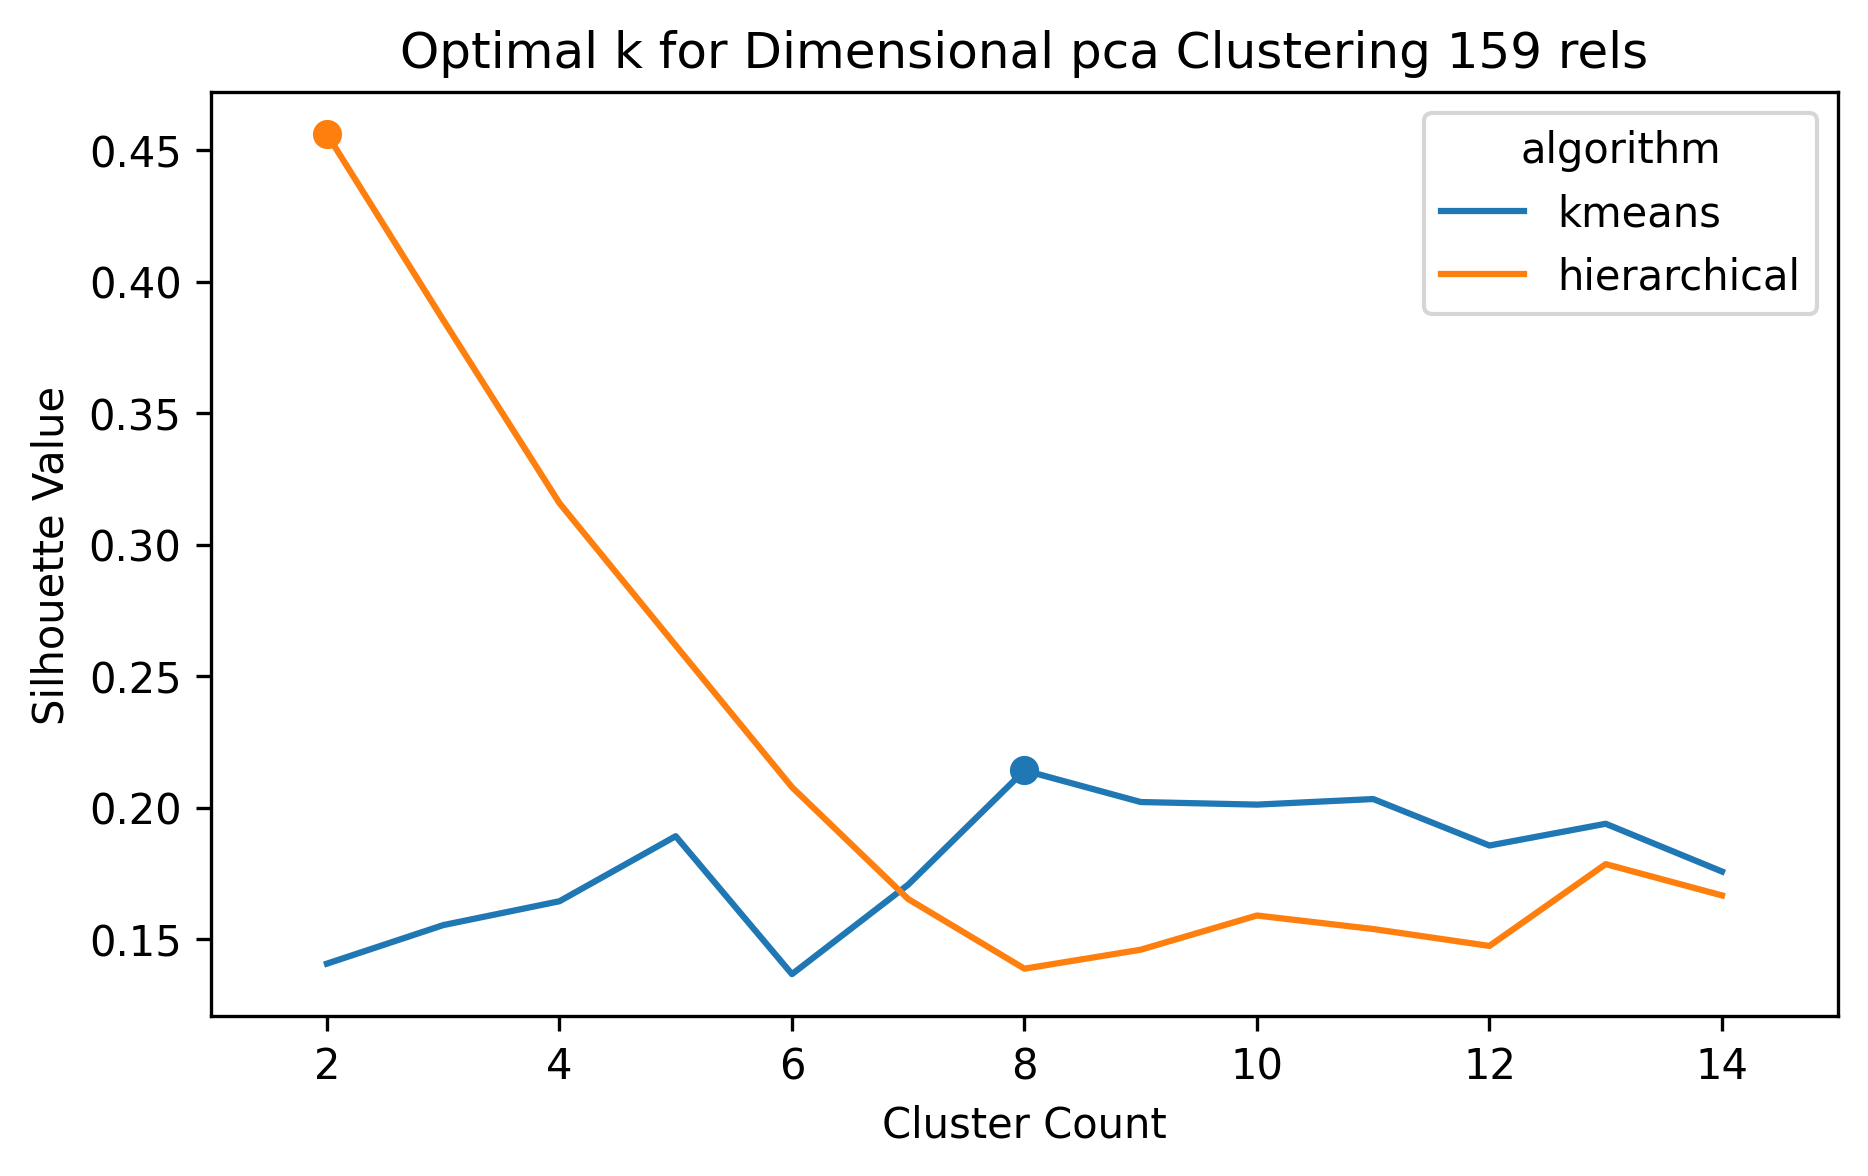

In [6]:
Within_pca_5c = pd.read_csv('./output_data/pca_results/scores_var.csv',index_col = 0,encoding='gbk')
optimalK(data_type='df',data=Within_pca_5c, algorithm1='kmeans', algorithm2='hierarchical', 
         random_state=random_seed, title="Optimal k for Dimensional pca Clustering 159 rels")

In [7]:
data = Within_pca_5c
ks = [2,3,4,5]
clust_results = data
for k in ks:
    model = KMeans(k, random_state=random_seed)
    model.fit(data)
    cluster_labels = model.fit_predict(data)
    clust_results['cl_k'+str(k)] = cluster_labels
clust_results.to_csv('./output_data/cluster_results.csv',encoding='utf-8-sig')

In [8]:
for n in range(len(clust_results['cl_k3'].unique())):
    each_cluster = clust_results.index[clust_results['cl_k3']==n]
    print("\nCluster "+str(n+1)+" Relationship:{}".format(len(each_cluster)))
    print(*clust_results.index[clust_results['cl_k3']==n], sep = ", ")


Cluster 1 Relationship:41
三从兄-三从弟, 义母-义女, 亲家-亲家, 兄妹, 兄弟, 养母-养女, 叔-嫂, 叔父-侄子, 同父异母兄-同父异母弟, 同父异母姐-同父异母妹, 堂伯-堂侄, 堂兄妹, 堂兄弟, 堂姐夫-堂内弟, 堂姐妹, 外祖母-外孙女, 夫妻, 妹夫-妻姐, 姐夫-妹夫, 姐夫-妻弟, 姐妹, 姐弟, 姑-嫂, 姑表兄妹, 姑表姐妹, 姑表姐弟, 姨表兄妹, 姨表姐妹, 姨表姐弟, 干爹-干儿子, 异父异母兄-异父异母妹, 异父异母姐-异父异母妹, 异父异母姐-异父异母弟, 族姐-族妹, 继兄-继弟, 继姐-继妹, 舅表兄弟, 舅表姐妹, 表兄弟, 表姐妹, 表嫂-表小叔

Cluster 2 Relationship:43
义母-义子, 义父-义女, 义父-义子, 从祖父-从孙子, 伯父-侄女婿, 伯父-侄媳, 伯父-侄子, 公公-儿媳, 养母-养子, 养父-养女, 再从兄-再从弟, 叔母-侄女, 叔母-侄子, 同母异父兄-同母异父弟, 同父异母兄-同父异母妹, 堂姐弟, 堂祖母-堂侄孙, 堂祖父-堂侄孙, 姑母-侄子, 姑父-侄子, 姑表兄弟, 姨父-外甥, 婆婆-儿媳, 岳母-女婿, 岳父-女婿, 弟媳-伯, 曾祖母-曾孙女, 曾祖母-曾孙子, 曾祖父-曾孙女, 母女, 母子, 父女, 父子, 继兄-继妹, 继外祖父-继外孙子, 继母-继女, 继母-继子, 继父-继女, 继祖母-继孙子, 舅公-甥孙, 舅母-外甥, 舅父-外甥, 表姐弟

Cluster 3 Relationship:32
从祖姑-从侄孙, 从祖母-从孙女, 伯母-侄女, 伯母-侄子, 养父-养子, 叔父-侄女, 外曾祖母-外曾孙, 外曾祖父-外曾孙, 外祖母-外孙子, 外祖父-外孙女, 外祖父-外孙子, 姑母-侄女, 姨母-外甥, 姨母-外甥女, 干妈-干女儿, 族伯叔-族侄, 曾祖父-曾孙子, 祖先-后代, 祖母-孙女, 祖母-孙子, 祖父-孙女, 祖父-孙子, 继外祖母-继外孙女, 继祖母-继孙女, 继祖父-继孙女, 继祖父-继孙子, 舅母-外甥女, 舅父-外甥女, 舅父-甥女婿, 舅表姐弟, 高祖母-玄孙, 高祖父-玄孙


In [9]:
# !pip install plotly
# !pip install --upgrade nbformat
# !pip install nbformat>=4.2.0

import plotly
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import pandas as pd

In [10]:
pca_5c_3k = pd.read_csv('./output_data/cluster_results.csv',
                       index_col=0,usecols=range(0,7))

pca_5c_3k.columns = ['Formality','Activeness','Valence','Exchange','Equality','cl_k3'] 
pca_5c_3k['Exchange'] = -pca_5c_3k['Exchange']
#pca_5c_3k['Equality'] = -pca_5c_3k['Equality']

# transform into range[0,1]
Equality_values = pca_5c_3k['Equality']
Exchange_values = pca_5c_3k['Exchange']
pca_5c_3k['Equality_plot'] = (Equality_values -Equality_values.min())/(Equality_values.max()-Equality_values.min())
pca_5c_3k['Exchange_plot'] = (Exchange_values -Exchange_values.min())/(Exchange_values.max()-Exchange_values.min())

pca_5c_3k['rel'] = pca_5c_3k.index
pca_5c_3k.loc[pca_5c_3k['cl_k3']==0,'cluster'] = 'Public'
pca_5c_3k.loc[pca_5c_3k['cl_k3']==1,'cluster'] = 'Private'
pca_5c_3k.loc[pca_5c_3k['cl_k3']==2,'cluster'] = 'Hostile'

pca_5c_3k.head()

,Formality,Activeness,Valence,Exchange,Equality,cl_k3,Equality_plot,Exchange_plot,rel,cluster
三从兄-三从弟,-0.114393,2.347020,1.391142,2.593489,-0.851616,0,0.356648,1.000000,三从兄-三从弟,Public
义母-义女,0.070789,-0.448328,0.168096,-0.969914,0.242945,0,0.539223,0.356995,义母-义女,Public
义母-义子,0.641796,-0.184213,0.010947,-0.651886,0.599014,1,0.598616,0.414382,义母-义子,Private
义父-义女,1.483913,1.058729,-0.279901,0.429573,1.750301,1,0.790652,0.609528,义父-义女,Private
义父-义子,1.441330,-1.602832,-1.096007,0.489062,1.293302,1,0.714424,0.620263,义父-义子,Private


In [11]:
fig = px.scatter_3d(pca_5c_3k,x='Activeness',y='Formality',z='Valence',
                    color='cluster',size='Equality_plot',size_max=70,
                    color_discrete_sequence=["#E45E62","#6594BE","#4EC186"],
                    #symbol='cluster',
                    #symbol_sequence= ['cross','square','circle'],
                    hover_name="rel",
                    hover_data={#'cl_k3':False, # remove species from hover data
                                'Equality_plot':False,
                                'Formality':':.2f','Activeness':':.2f',
                                'Valence':':.2f','Exchange':':.2f','Equality':':.2f'})

#fig.update_scenes(xaxis_autorange="reversed")
#fig.update_scenes(zaxis_autorange="reversed")
# xaxis.backgroundcolor is used to set background color
fig.update_layout(scene = dict(
                    # Formality
#                     xaxis = dict(
#                          backgroundcolor="#4EC186",
#                          #gridcolor="#4EC186",
#                          showgrid=False,zeroline=False,
#                          showbackground=True,
#                          zerolinecolor="white",),
#                     # Activeness
#                     yaxis = dict(
#                         backgroundcolor="#E45E62",
#                         #gridcolor="#E45E62",
#                         showgrid=False,zeroline=False,
#                         showbackground=True,
#                         zerolinecolor="white"),
#                     zaxis = dict(
#                         backgroundcolor="#6594BE",
#                         #gridcolor="#6594BE",
#                         showgrid=False,zeroline=False,
#                         showbackground=True,
#                         zerolinecolor="white",),
                        ),
                    # legend
                  legend=dict(#font=dict(size= 20),
                    yanchor="top",
                    y=0.99,
                    xanchor="left",
                    x=0.01),  
                  
                    width=1000,height=1000,
                    font_size =20
#                     margin=dict(
#                     r=10, l=100,
#                     b=20, t=15),
                  #showlegend=True
                  )   